# Retail Sales Analysis — Superstore Datase -->
In this project, I have taken the data of super store sales (2015-2018) to perforn analysis and understand the sales trend, top categories and regional performances (tools: pandas, matplotlib)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('Super store sales.csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [2]:
# Check data types and non-null counts for all columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

## Data Cleaning
Checking for missing values and duplicate rows before analysis.

In [3]:
# Check for missing values in each column
print(df.isnull().sum())

# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64
Duplicate rows: 0


No duplicate rows found. Postal Code has 11 missing values, but this column is not used in the analysis, so it was left as is.

In [4]:
# Convert Order Date and Ship Date to datetime format
# dayfirst=True is used since dates are in DD/MM/YYYY format
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

# Extract year and month for time-based analysis
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month_name()

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   str           
 2   Order Date     9800 non-null   datetime64[us]
 3   Ship Date      9800 non-null   datetime64[us]
 4   Ship Mode      9800 non-null   str           
 5   Customer ID    9800 non-null   str           
 6   Customer Name  9800 non-null   str           
 7   Segment        9800 non-null   str           
 8   Country        9800 non-null   str           
 9   City           9800 non-null   str           
 10  State          9800 non-null   str           
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   str           
 13  Product ID     9800 non-null   str           
 14  Category       9800 non-null   str           
 15  Sub-Category   9800 non-null   s

## Analysis

### Q1: How have sales changed over time?

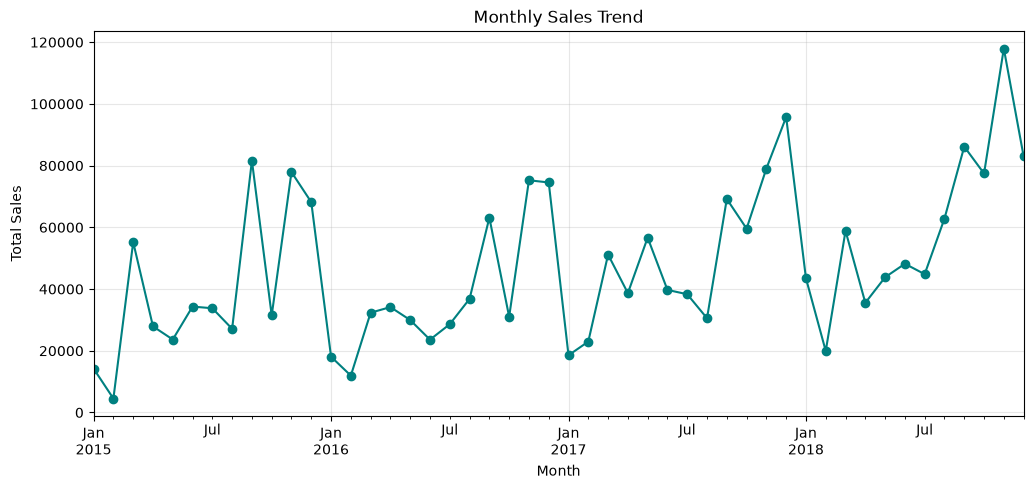

In [5]:
# Group total sales by month
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()

# Plot monthly sales trend
plt.figure(figsize=(12,5))
monthly_sales.plot(kind='line', marker='o', color='teal')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True, alpha=0.3)
plt.show()

**Insight:** Total sales show an upward trend, indicating business growth. Additionally, sharp spikes occur at the end of each year, highlighting sales seasonality. This could be due to end-of-season sales or specific product categories. This pattern signals the business to increase stock and staffing before the peak season begins.

### Q2: Which category generates the most sales?

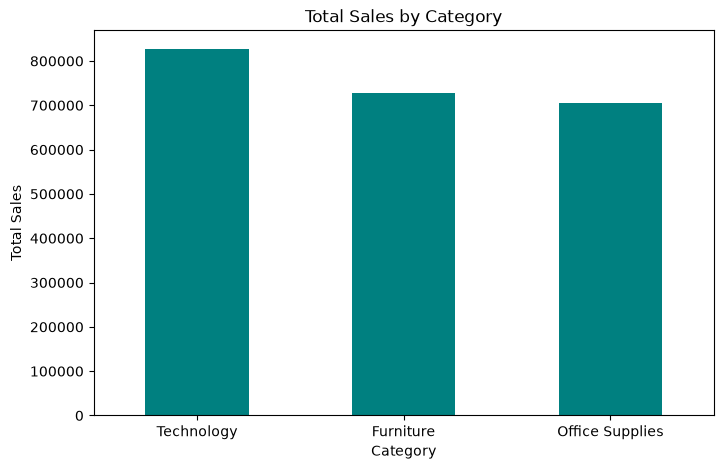

In [6]:
# Group total sales by category, sorted highest to lowest
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

# Plot category-wise sales
plt.figure(figsize=(8,5))
category_sales.plot(kind='bar', color='teal')
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.show()

**Insight:** The Technology category generates the most revenue, but sales across all three categories are quite close. This shows that the business doesn't rely on a single category for sales, which is good from a risk management perspective because if sales of one category slow down, it won't severely impact the business.

### Q3: Which region generates the most sales?

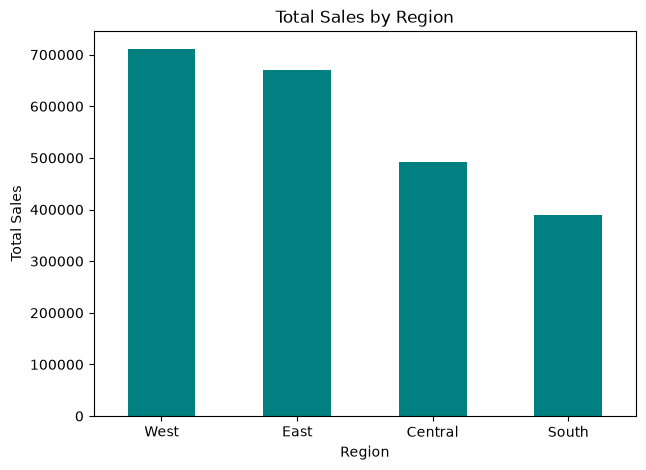

In [7]:
# Group total sales by region, sorted highest to lowest
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

# Plot region-wise sales
plt.figure(figsize=(7,5))
region_sales.plot(kind='bar', color='teal')
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.show()

**Insight:** The West region generates the highest sales (~$710K), followed by the East (~$670K).The Central and South regions lag significantly behind, with the South recording the lowest sales (~$390K). This disparity may be due to higher population and business density in the West and East regions-indicating that the company could benefit from focusing marketing or
expansion efforts on the South region

### Q4: What are the top 10 best-selling products?

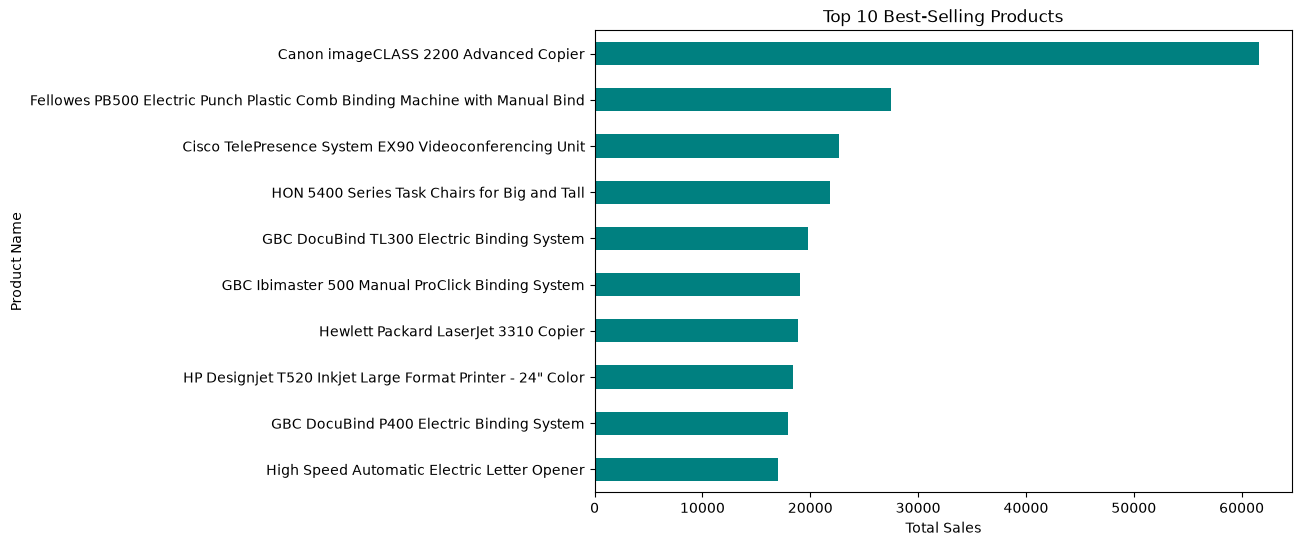

In [8]:
# Group total sales by product, take top 10
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

# Plot top 10 products as horizontal bar chart
plt.figure(figsize=(9,6))
top_products.plot(kind='barh', color='teal')
plt.title('Top 10 Best-Selling Products')
plt.xlabel('Total Sales')
plt.gca().invert_yaxis()  # highest value on top
plt.show()

**Insight:** The Canon imageCLASS 2200 Advanced Copier is the top-selling
product by a significant margin, generating roughly double the revenue of the second-place
item, the Fellowes PB500($6OK vs.$27K)-making it a clear outlier and best-seller. The top 10products consist mostly of office equipment (binding machines, copiers, printers), indicating that high-value office electronics generate the bulk of the revenue rather than smaller items.

### Q5: How is sales split across customer segments?

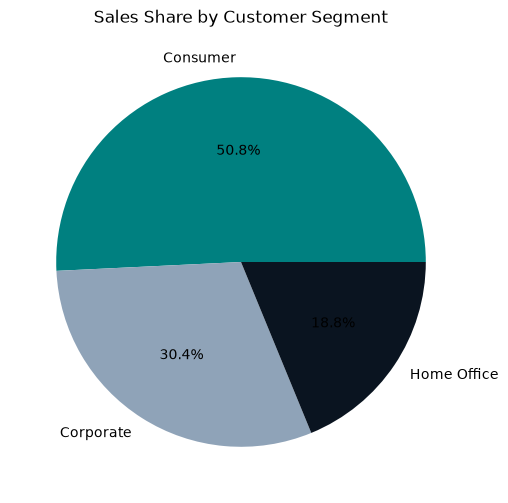

In [9]:
# Group total sales by customer segment
segment_sales = df.groupby('Segment')['Sales'].sum()

# Plot segment sales share as pie chart
plt.figure(figsize=(6,6))
plt.pie(segment_sales, labels=segment_sales.index, autopct='%1.1f%%',
        colors=['teal', '#8fa3b8', '#0a1420'])
plt.title('Sales Share by Customer Segment')
plt.show()

**Insight:** The Consumer segment accounts for 50.8% of total sales-more than the Corporate (30.4%) and Home Office (18.8%) segments combined. Since the core revenue comes from individual consumers, focusing marketing and promotional efforts on this segment will yield the highest return.

### Q6: Which shipping mode is used most often?

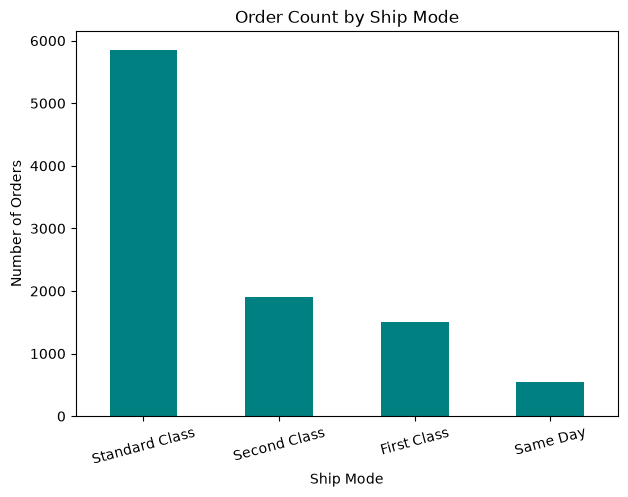

In [10]:
# Count number of orders per shipping mode
ship_mode_counts = df['Ship Mode'].value_counts()

# Plot order count by ship mode
plt.figure(figsize=(7,5))
ship_mode_counts.plot(kind='bar', color='teal')
plt.title('Order Count by Ship Mode')
plt.xlabel('Ship Mode')
plt.ylabel('Number of Orders')
plt.xticks(rotation=15)
plt.show()

**Insight:** Standard Class is the most frequently used shipping method (~5, 850 orders), 
exceeding the volume of all other three options (Second Class, First Class, Same Day)
combined. This suggests that the majority of customers prioritize cost-effective, standard delivery over faster shipping speeds.

## Key findings
Overall sales grew from 2015 to 2018, demonstrating strong seasonality-peaking at the end of the year (September-December) and hitting the lowest point in January.
Technology generates the highest revenue, though all three categories remain reasonably balanced.
The West and East regions generate the most sales, while the South generates the least-representing a potential opportunity for regional expansion.
The Canon imageCLASS 2200 Copier is by far the top-selling product, outperforming other top products by a significant margin.
The Consumer segment alone accounts for over 50% of total sales.
Standard Class shipping is the most popular option, indicating that customers prioritize cost efficiency and reliability over delivery speed.